# Phase IV Final — Full Code (from scratch)
**Goal:** Reduce **False Negatives (FN)** in breast cancer diagnosis under class imbalance.

This notebook implements and compares:
1) **Baseline XGBoost** (no imbalance handling)  
2) **SMOTE + XGBoost** (Phase III style; may introduce synthetic noise)  
3) **Phase IV Improved:** **Feature Selection (SelectKBest)** + **ADASYN** + **Cost-Sensitive XGBoost**

Outputs:
- Metrics table (Recall/Precision/F1/AUC/FN/FP/TP/TN) saved to CSV
- Confusion matrices saved as PNG
- ROC curve comparison saved as PNG
- FN & Recall bar charts saved as PNG

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    recall_score, precision_score, f1_score,
    roc_auc_score, roc_curve
)

from imblearn.over_sampling import SMOTE, ADASYN
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1) Load dataset
In `sklearn.datasets.load_breast_cancer`:
- original labels: `0 = malignant`, `1 = benign`
We convert to:
- `1 = malignant` (positive class), `0 = benign` to focus on **FN reduction**.

In [90]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Target names:", data.target_names)  # ['malignant', 'benign']
print("Original labels distribution (0=malignant, 1=benign):")
print(y.value_counts())

# Convert so malignant = 1 (positive), benign = 0 (negative)
y_bin = (y == 0).astype(int)
print("\nConverted labels distribution (1=malignant):")
print(y_bin.value_counts())

Target names: ['malignant' 'benign']
Original labels distribution (0=malignant, 1=benign):
target
1    357
0    212
Name: count, dtype: int64

Converted labels distribution (1=malignant):
target
0    357
1    212
Name: count, dtype: int64


## 2) Train/Test split + Scaling
- Stratified split (80/20)
- Standardize features (fit on train only)

In [91]:
base_params = dict(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    eval_metric="logloss"
)

In [92]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin, test_size=0.20, random_state=RANDOM_STATE, stratify=y_bin
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Train distribution:", y_train.value_counts().to_dict())
print("Test distribution:", y_test.value_counts().to_dict())

Train distribution: {0: 285, 1: 170}
Test distribution: {0: 72, 1: 42}


## 3) Helpers (metrics + plots)

In [93]:
def cm_parts(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn, fp, fn, tp

def evaluate(name, model, X_te, y_te, y_pred):
    y_prob = model.predict_proba(X_te)[:, 1]
    auc = roc_auc_score(y_te, y_prob)

    rec = recall_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    tn, fp, fn, tp = cm_parts(y_te, y_pred)

    return {
        "Model": name,
        "Recall": rec,
        "Precision": prec,
        "F1-Score": f1,
        "AUC-ROC": auc,
        "FN": fn,
        "FP": fp,
        "TP": tp,
        "TN": tn
    }

def plot_cm(y_true, y_pred, title, save_path=None):
    disp = ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred))
    disp.plot()
    plt.title(title)
    plt.grid(False)
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=200)
    plt.show()

## 4) Base XGBoost config

## 5) Model A — Baseline XGBoost

In [94]:
baseline_model = XGBClassifier(**base_params)
baseline_model.fit(X_train_sc, y_train)
y_pred_baseline = baseline_model.predict(X_test_sc)

## 6) Model B — SMOTE + XGBoost (Phase III)
SMOTE is applied **only** on training data.

In [95]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)

smote_model = XGBClassifier(**base_params)
smote_model.fit(X_train_sm, y_train_sm)
y_pred_smote = smote_model.predict(X_test_sc)

## 7) Model C — Phase IV: Feature Selection + ADASYN + Cost-Sensitive XGBoost

In [96]:
# Feature Selection (fit on TRAIN only)
k_features = 15
selector = SelectKBest(score_func=f_classif, k=k_features)
X_train_sel = selector.fit_transform(X_train_sc, y_train)
X_test_sel  = selector.transform(X_test_sc)

# ADASYN oversampling on selected TRAIN data only
adasyn = ADASYN(random_state=RANDOM_STATE)
X_train_ad, y_train_ad = adasyn.fit_resample(X_train_sel, y_train)

# Cost-sensitive weight computed from ORIGINAL train distribution (before oversampling)
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print("scale_pos_weight:", scale_pos_weight)

adasyn_cost_model = XGBClassifier(**base_params, scale_pos_weight=scale_pos_weight)
adasyn_cost_model.fit(X_train_ad, y_train_ad)
y_pred_adasyn_cost = adasyn_cost_model.predict(X_test_sel)

scale_pos_weight: 1.6764705882352942


## 8) Results table + Save CSV

In [98]:
rows = [
    evaluate("Baseline (XGB)", baseline_model, X_test_sc, y_test, y_pred_baseline),
    evaluate("SMOTE + XGB (Phase III)", smote_model, X_test_sc, y_test, y_pred_smote),
    evaluate("FeatureSel + ADASYN + Cost-XGB (Phase IV)", adasyn_cost_model, X_test_sel, y_test, y_pred_adasyn_cost),
]

results_df = pd.DataFrame(rows)
results_df

,Model,Recall,Precision,F1-Score,AUC-ROC,FN,FP,TP,TN
0,Baseline (XGB),0.928571,1.000000,0.962963,0.993717,3,0,39,72
1,SMOTE + XGB (Phase III),0.928571,1.000000,0.962963,0.995370,3,0,39,72
2,FeatureSel + ADASYN + Cost-XGB (Phase IV),1.000000,0.954545,0.976744,0.998347,0,2,42,70


In [99]:
results_df.to_csv("phase4_full_results.csv", index=False)
print("Saved: phase4_full_results.csv")

Saved: phase4_full_results.csv


## 9) Confusion matrices (saved as PNG)

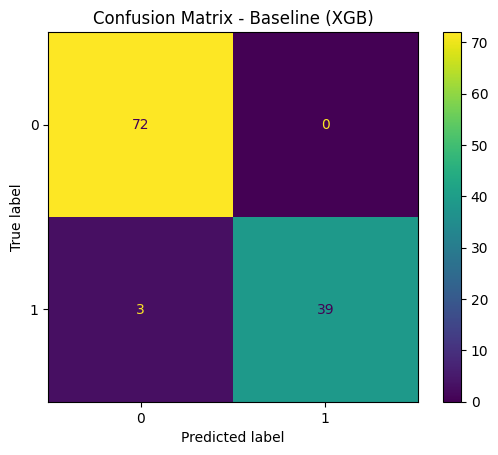

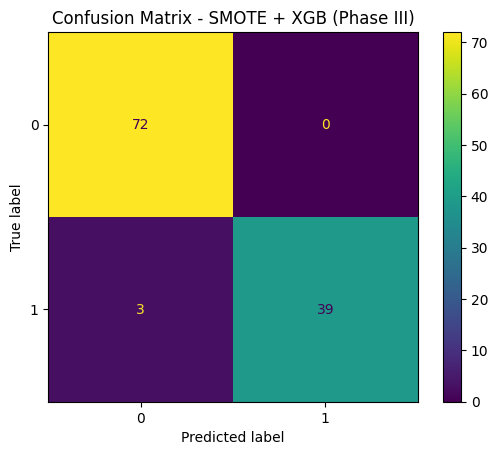

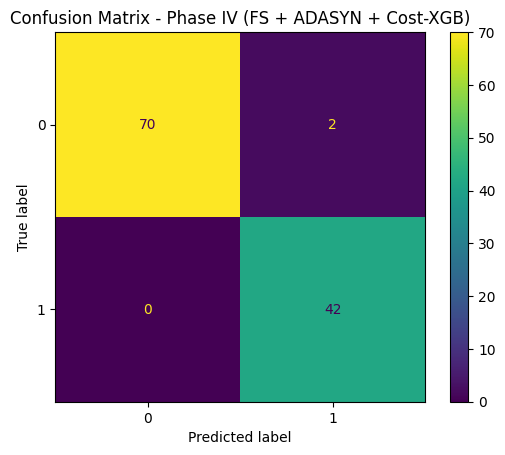

Saved CM images.


In [100]:
plot_cm(y_test, y_pred_baseline, "Confusion Matrix - Baseline (XGB)", "cm_baseline.png")
plot_cm(y_test, y_pred_smote, "Confusion Matrix - SMOTE + XGB (Phase III)", "cm_smote_phase3.png")
plot_cm(y_test, y_pred_adasyn_cost, "Confusion Matrix - Phase IV (FS + ADASYN + Cost-XGB)", "cm_phase4_adasyn_fs_cost.png")

print("Saved CM images.")

## 10) ROC curve comparison (saved as PNG)
Note: Phase IV uses selected features for test (`X_test_sel`).

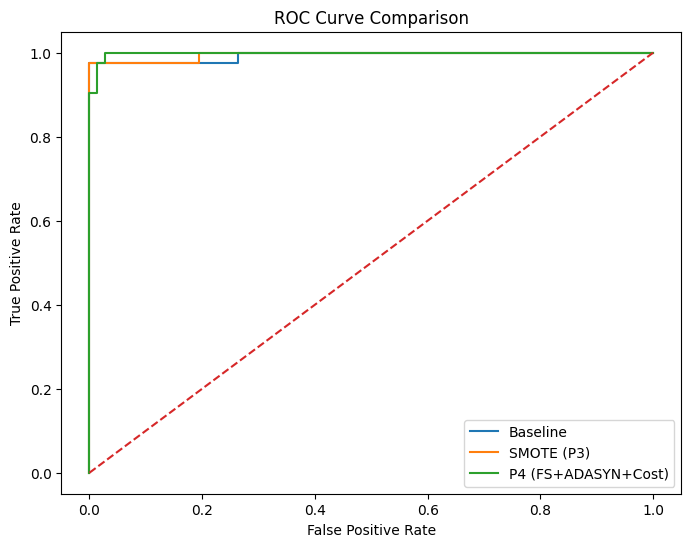

Saved: roc_comparison.png


In [101]:
plt.figure(figsize=(8,6))

# Baseline
y_prob = baseline_model.predict_proba(X_test_sc)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label="Baseline")

# SMOTE (P3)
y_prob = smote_model.predict_proba(X_test_sc)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label="SMOTE (P3)")

# Phase IV
y_prob = adasyn_cost_model.predict_proba(X_test_sel)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label="P4 (FS+ADASYN+Cost)")

plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.savefig("roc_comparison.png", bbox_inches="tight", dpi=200)
plt.show()

print("Saved: roc_comparison.png")

## 11) FN & Recall bar charts (saved as PNG)

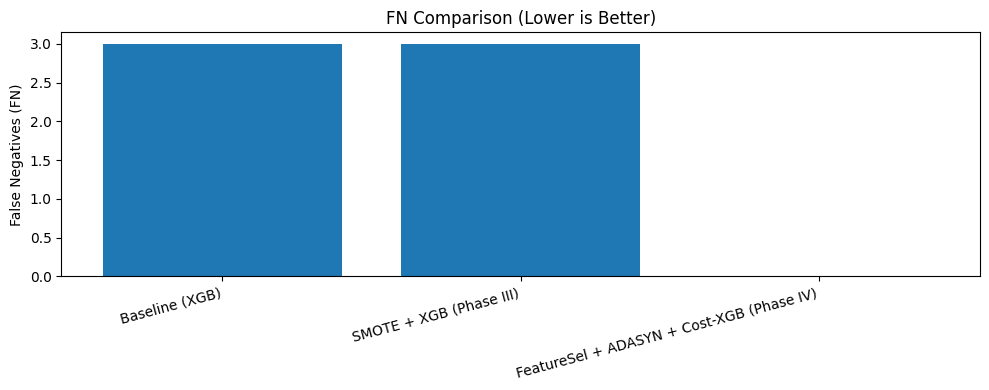

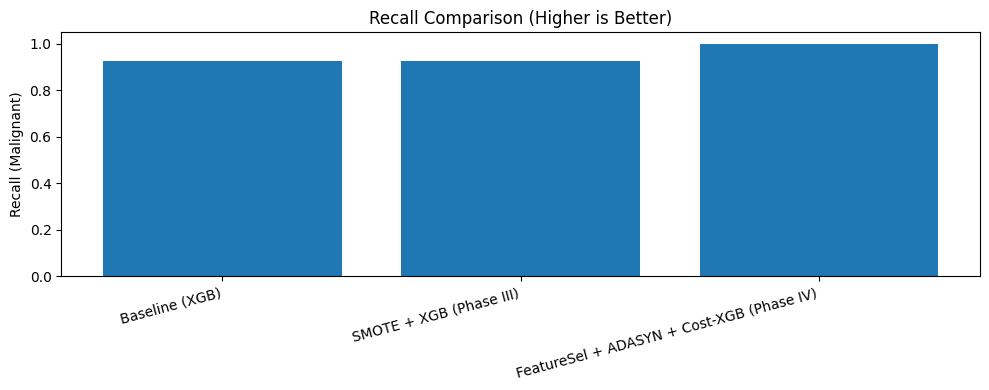

Saved: fn_comparison.png, recall_comparison.png


In [102]:
plt.figure(figsize=(10,4))
plt.bar(results_df["Model"], results_df["FN"])
plt.xticks(rotation=15, ha="right")
plt.ylabel("False Negatives (FN)")
plt.title("FN Comparison (Lower is Better)")
plt.tight_layout()
plt.savefig("fn_comparison.png", dpi=200)
plt.show()

plt.figure(figsize=(10,4))
plt.bar(results_df["Model"], results_df["Recall"])
plt.xticks(rotation=15, ha="right")
plt.ylabel("Recall (Malignant)")
plt.title("Recall Comparison (Higher is Better)")
plt.tight_layout()
plt.savefig("recall_comparison.png", dpi=200)
plt.show()

print("Saved: fn_comparison.png, recall_comparison.png")

## 12) Quick summary

In [103]:
best_fn = results_df.loc[results_df["FN"].idxmin()]
best_recall = results_df.loc[results_df["Recall"].idxmax()]

print("Lowest FN:", best_fn["Model"], "FN=", int(best_fn["FN"]))
print("Highest Recall:", best_recall["Model"], "Recall=", float(best_recall["Recall"]))

Lowest FN: FeatureSel + ADASYN + Cost-XGB (Phase IV) FN= 0
Highest Recall: FeatureSel + ADASYN + Cost-XGB (Phase IV) Recall= 1.0
